<a href="https://colab.research.google.com/github/ChristenKnight/STAT-7220-Applied-Experimental-Design/blob/Week-2/Dog_Toy_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dog Toy Practice





In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "ChristenKnight"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Comparative Experiments"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/ChristenKnight/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/ChristenKnight/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Comparative Experiments


## Specify the outcome and independent variables. What lurking variables might be present?
  Outcome Varaible is the pressure the toy can withstand.
  The independent variable is the Formula of Rubber


## Briefly explain why a completely randomized design might be appropriate in this context
  Complete Random design is appropriate because we have two mutially exclusive formulars we would like to compare to each other, with no other lurking variables.

## Perform an appropriate exploratory analysis


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Formulation  120 non-null    object 
 1   PSI          120 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.0+ KB
                   mean        std
Formulation                       
Formula 1    278.432167  12.450986
Formula 2    291.924333  16.644723


Text(0, 0.5, 'PSI')

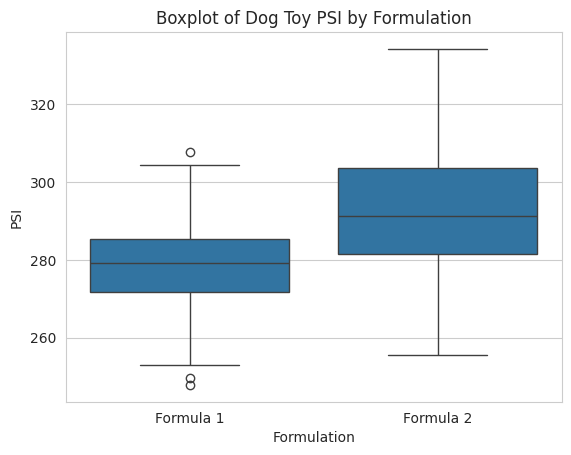

In [5]:
## Importing Packages needed for analysis ##

import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Import Dog Toy Data ##

dog_toys = pd.read_excel("Dog Toys.xlsx")

## Checking data ##

dog_toys.info()

## Summar Stats grouped by Formula ##

summary_stats = dog_toys.groupby('Formulation')['PSI'].agg(['mean','std'])

print(summary_stats)

## Visulaziations ##

sns.set_style("whitegrid")

## Create Boxplot ##

sns.boxplot(x="Formulation", y="PSI",data=dog_toys)

plt.title("Boxplot of Dog Toy PSI by Formulation", loc='center')
plt.xlabel("Formulation")
plt.ylabel("PSI")

Formula 2 dog toys can withstand 20 more PSI than For,mula 1 dog toys. Formula 2 dog toys has about 20 more PSI, with an average standard deviarion of 14 PSI with is $1.5σ$, meaning a moderate difference in the two formulas

## Perform an appropriate inferential analysis (including the specification of $H_0$ and $H_1$)

## Our Hypothesis
$H_0$: Mean PSI between Formulation 1 and Formulation 2 is the same
  
$H_1$: Mean PSI between Formulation 1 and Formulation 2 is different




In [11]:
## Install statsmodels.api ##
#%pip install statsmodels

## Import statsmodels ##

import statsmodels.api as sm
from statsmodels.formula.api import ols

## One-Way ANOVA Model ##

mod = ols("PSI ~ Formulation", data=dog_toys).fit()

## ANOVA table ##

aov_tab = sm.stats.anova_lm(mod,typ=1)

##  Significance Column ##

aov_tab["Significance"] = np.where(aov_tab["PR(>F)"]<0.05,"Significant","Not Significant")

print(aov_tab)


                df        sum_sq      mean_sq          F    PR(>F)  \
Formulation    1.0   5461.156841  5461.156841  25.278813  0.000002   
Residual     118.0  25492.356292   216.036918        NaN       NaN   

                Significance  
Formulation      Significant  
Residual     Not Significant  


## Provide contextual conclusions -- which formulation seems more durable?

